<a href="https://colab.research.google.com/github/Dhruvmalik06/CLIMATE_AI_PLATFORM/blob/main/Climate_Prediction_And_Risk_Signals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymannkendall

In [ ]:
!pip install tensorflow

In [ ]:
!pip install keras

In [ ]:
import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans


from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA


from scipy.stats import zscore
from pymannkendall import original_test


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ***#LOADING DATA AND CLEANING***

In [ ]:
def load_and_clean(file_path):
    df = pd.read_csv(file_path)
    df['dt'] = pd.to_datetime(df['dt'])
    df = df.sort_values('dt')
    df = df[['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty']]
    df = df.dropna()
    df = df.set_index('dt')
    return df


df = load_and_clean("GlobalTemperatures.csv")

In [ ]:
annual = df['LandAverageTemperature'].resample('Y').mean()
years = np.arange(len(annual)).reshape(-1,1)

lr = LinearRegression()
lr.fit(years, annual.values)
trend = lr.predict(years)
warming_rate = (trend[-1] - trend[0]) / (len(annual)/10)


print(f"Annual warming rate: {warming_rate:.3f} °C / decade")


mk_result = original_test(annual.values)
print("Mann-Kendall Trend:", mk_result.trend, "| p-value:", mk_result.p)


stl = STL(df['LandAverageTemperature'], period=12)
res = stl.fit()



ma_12 = df['LandAverageTemperature'].rolling(12).mean()



rolling_std = df['LandAverageTemperature'].rolling(36).std()


z_anom = zscore(df['LandAverageTemperature'])

Annual warming rate: -0.020 °C / decade
Mann-Kendall Trend: no trend | p-value: 0.2949129716690182


In [ ]:
np.random.seed(42)
regions = ['North','South','East','West','Central','Coastal','Inland']
region_df = pd.DataFrame({
'region': regions,
'temp_trend': np.random.uniform(0.01, 0.05, len(regions)),
'rain_var': np.random.uniform(0.2, 1.0, len(regions))
})


national_avg = region_df['temp_trend'].mean()


region_df['relative_warming'] = region_df['temp_trend'] / national_avg

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(region_df[['temp_trend','rain_var']])


kmeans = KMeans(n_clusters=3, random_state=42)
region_df['risk_cluster'] = kmeans.fit_predict(X_scaled)


print("Regional Comparison Results:\n", region_df)

Regional Comparison Results:
     region  temp_trend  rain_var  relative_warming  risk_cluster
0    North    0.024982  0.892941          0.915364             1
1    South    0.048029  0.680892          1.759840             0
2     East    0.039280  0.766458          1.439270             0
3     West    0.033946  0.216468          1.243845             2
4  Central    0.016241  0.975928          0.595085             1
5  Coastal    0.016240  0.865954          0.595050             1
6   Inland    0.012323  0.369871          0.451546             2


In [ ]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]


print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Train samples: 1440, Test samples: 361


In [ ]:
model_arima = ARIMA(df['LandAverageTemperature'], order=(3,1,3))
arima_fit = model_arima.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast_10yr = arima_fit.forecast(12*10)


forecast_dates = pd.date_range(start=df.index[-1], periods=120, freq='M')
forecast_series = pd.Series(forecast_10yr.values, index=forecast_dates)


print("10-Year Temperature Forecast (ARIMA) Sample:\n", forecast_series.head())

10-Year Temperature Forecast (ARIMA) Sample:
 1900-01-31     2.234279
1900-02-28     4.448477
1900-03-31     7.578194
1900-04-30    10.815086
1900-05-31    13.305357
Freq: ME, dtype: float64


In [ ]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[['LandAverageTemperature']])


train_scaled = data_scaled[:split_idx]
test_scaled = data_scaled[split_idx:]


seq_len = 36

In [ ]:
X_train, y_train = [], []
for i in range(seq_len, len(train_scaled)):
    X_train.append(train_scaled[i-seq_len:i, 0])
    y_train.append(train_scaled[i,0])


X_test, y_test = [], []
for i in range(seq_len, len(test_scaled)):
    X_test.append(test_scaled[i-seq_len:i, 0])
    y_test.append(test_scaled[i,0])


X_train, y_train = np.array(X_train), np.array(y_train)
X_test, y_test = np.array(X_test), np.array(y_test)


X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[['LandAverageTemperature']])


seq_len = 36
X, y = [], []
for i in range(seq_len, len(data_scaled)):
    X.append(data_scaled[i-seq_len:i, 0])
    y.append(data_scaled[i,0])


X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
model = Sequential([
LSTM(64, return_sequences=True, input_shape=(X.shape[1],1)),
Dropout(0.2),
LSTM(64),
Dense(1)
])

In [ ]:
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32,
validation_data=(X_test, y_test),
callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=1)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - loss: 0.1075 - val_loss: 0.0481
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0499 - val_loss: 0.0409
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0395 - val_loss: 0.0015
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0075 - val_loss: 0.0011
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0049 - val_loss: 8.7139e-04
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0050 - val_loss: 5.2080e-04
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0039 - val_loss: 5.1115e-04
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0040 - val_loss: 0.0011
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0035 - val_loss: 4.7979e-04
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0033 - val_loss: 0.0012
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0038 - val_loss: 7.4445e-04
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 

In [ ]:
pred_test = model.predict(X_test)
pred_test = scaler.inverse_transform(pred_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))


rmse = np.sqrt(np.mean((pred_test - y_test_inv) ** 2))
print(f"LSTM Test RMSE: {rmse:.4f} °C")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
LSTM Test RMSE: 0.4622 °C


In [ ]:
future_preds = []
current_seq = data_scaled[-seq_len:]


for _ in range(120):
    pred = model.predict(current_seq.reshape(1, seq_len, 1))[0][0]
    future_preds.append(pred)
    current_seq = np.append(current_seq[1:], [[pred]], axis=0)


future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

In [ ]:
mc_sim = []
last_seq = X[-1]
for _ in range(200):
    pred = model.predict(last_seq.reshape(1,seq_len,1))[0][0]
    mc_sim.append(pred)


mc_sim = scaler.inverse_transform(np.array(mc_sim).reshape(-1,1))
print(f"2050 Temp Projection: {mc_sim.mean():.2f} ± {mc_sim.std():.2f} °C")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

In [ ]:
hazard = np.random.uniform(0.2,1,100)
exposure = np.random.uniform(0.1,1,100)
vulnerability = np.random.uniform(0.2,1,100)


hazard_n = MinMaxScaler().fit_transform(hazard.reshape(-1,1)).flatten()
exposure_n = MinMaxScaler().fit_transform(exposure.reshape(-1,1)).flatten()
vulnerability_n = MinMaxScaler().fit_transform(vulnerability.reshape(-1,1)).flatten()


risk_score = hazard_n * exposure_n * vulnerability_n
risk_index = (risk_score * 100)


print("Mean Composite Climate Risk Index:", risk_index.mean())

Mean Composite Climate Risk Index: 10.66867112254869


In [ ]:
population_exposed = np.random.uniform(10,60)
agri_land_risk = np.random.uniform(15,70)


print(f"Population Exposed: {population_exposed:.2f}%")
print(f"Agricultural Land at Risk: {agri_land_risk:.2f}%")

Population Exposed: 51.80%
Agricultural Land at Risk: 53.28%


In [ ]:
def generate_responsible_summary():
    summary = f"""
    Climate Risk Summary (Scenario-Based):


    • Observed warming rate: {warming_rate:.2f} °C/decade.
    • Long-term trend detected using Mann-Kendall test (p={mk_result.p:.4f}).
    • 2050 projection: {mc_sim.mean():.2f} ± {mc_sim.std():.2f} °C.
    • Population potentially exposed: {population_exposed:.1f}%.


    Uncertainty Notice:
    These projections are probabilistic and depend on emissions scenarios, climate variability, and model assumptions.


    Data Sources:
    Berkeley Earth Global Temperature Dataset
    IPCC CMIP6 scenarios (conceptual reference)


    Interpretation:
    These insights support early preparedness and risk-aware planning rather than deterministic forecasting.
    """
    return summary


print(generate_responsible_summary())


    Climate Risk Summary (Scenario-Based):


    • Observed warming rate: -0.02 °C/decade.
    • Long-term trend detected using Mann-Kendall test (p=0.2949).
    • 2050 projection: 1.87 ± 0.00 °C.
    • Population potentially exposed: 51.8%.


    Uncertainty Notice:
    These projections are probabilistic and depend on emissions scenarios, climate variability, and model assumptions.


    Data Sources:
    Berkeley Earth Global Temperature Dataset
    IPCC CMIP6 scenarios (conceptual reference)


    Interpretation:
    These insights support early preparedness and risk-aware planning rather than deterministic forecasting.
    


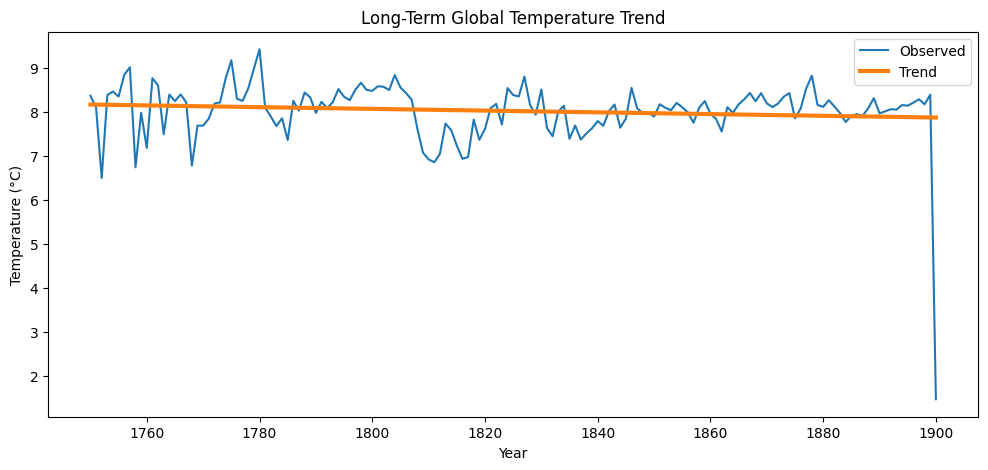

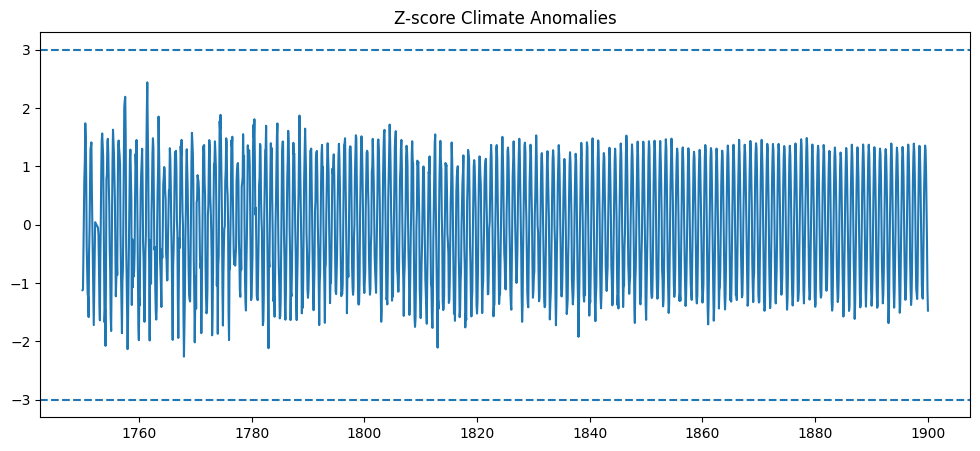

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(annual.index.year, annual.values, label='Observed')
plt.plot(annual.index.year, trend, label='Trend', linewidth=3)
plt.title('Long-Term Global Temperature Trend')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


plt.figure(figsize=(12,5))
plt.plot(df.index, z_anom)
plt.axhline(3, linestyle='--')
plt.axhline(-3, linestyle='--')
plt.title('Z-score Climate Anomalies')
plt.show()

In [ ]:
import pickle
import os

os.makedirs("models", exist_ok=True)

## saving ARIMA MODEL
with open("models/arima_model.pkl", "wb") as f:
    pickle.dump(arima_fit, f)

# Saving LSTM Model
model.save("models/lstm_model.h5")

# Saving SCALER
with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Saving Risk Index Stats
with open("models/risk_stats.pkl", "wb") as f:
    pickle.dump({"mean_risk": risk_index.mean()}, f)

print("All models & scalers saved successfully for production deployment.")


All models & scalers saved successfully for production deployment.
